# Task 2: Credit Card Fraud Detection
**Objective:** Build and evaluate ML models (Logistic Regression, Decision Tree, Random Forest) to detect fraudulent credit card transactions on an imbalanced dataset.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

## Step 1: Load and Inspect Dataset

In [7]:
# Load credit card dataset
df = pd.read_csv('fraudTest.csv')

# Handle missing values if any exist in target
df.dropna(subset=['is_fraud'], inplace=True)

print("First 5 rows:")
print(df.head())

print("\nClass Distribution (0 = Legitimate, 1 = Fraud):")
print(df['is_fraud'].value_counts())

# Check percentage of fraud
fraud_percentage = (df['is_fraud'].value_counts()[1] / len(df)) * 100
print(f"\nFraudulent Transactions: {fraud_percentage:.2f}% of total data")

First 5 rows:
   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2020-06-21 12:14:25  2291163933867244   
1           1   2020-06-21 12:14:33  3573030041201292   
2           2   2020-06-21 12:14:53  3598215285024754   
3           3   2020-06-21 12:15:15  3591919803438423   
4           4   2020-06-21 12:15:17  3526826139003047   

                               merchant        category    amt   first  \
0                 fraud_Kirlin and Sons   personal_care   2.86    Jeff   
1                  fraud_Sporer-Keebler   personal_care  29.84  Joanne   
2  fraud_Swaniawski, Nitzsche and Welch  health_fitness  41.28  Ashley   
3                     fraud_Haley Group        misc_pos  60.05   Brian   
4                 fraud_Johnston-Casper          travel   3.19  Nathan   

       last gender                       street  ...      lat      long  \
0   Elliott      M            351 Darlene Green  ...  33.9659  -80.9355   
1  Williams      F             3638 Marsh Union 

## Step 2: Feature Scaling & Train-Test Split
Scale the transaction amount and split the data into training (80%) and testing (20%) sets using stratified sampling to preserve class ratios.

In [8]:
# Scale the transaction amount column ('amt')
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df[['amt']])

# Select numerical features for modeling
feature_cols = ['scaled_amount', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long']

# Separate features (X) and target (y)
X = df[feature_cols]
y = df['is_fraud']

# Stratified Split to maintain fraud ratio in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (139744, 7)
X_test shape: (34936, 7)


## Step 3: Train & Compare Classifiers
We evaluate the three required algorithms using class weighting to handle the imbalanced fraud data[cite: 1]:
1. Logistic Regression
2. Decision Tree
3. Random Forest

In [9]:
# Define models with class_weight='balanced' to handle imbalance
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1)
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })

# Format and display results table
results_df = pd.DataFrame(results)
print("\n=== Fraud Detection Model Performance Comparison ===")
print(results_df.to_string(index=False))

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...

=== Fraud Detection Model Performance Comparison ===
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.176866   0.004297 0.837838  0.008550 0.505946
      Decision Tree  0.995420   0.458333 0.445946  0.452055 0.721852
      Random Forest  0.997252   0.882353 0.405405  0.555556 0.702588


## Step 4: Visualizing Performance (Confusion Matrix)

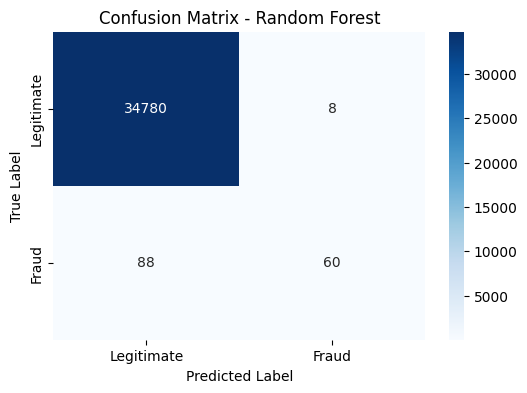

In [11]:
# Confusion Matrix for Random Forest
rf_model = models['Random Forest']
y_pred_rf = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Step 5: Test Model on Sample Fraudulent Transaction

In [12]:
# Test prediction on a real fraudulent transaction from test set
fraud_indices = y_test[y_test == 1].index

if len(fraud_indices) > 0:
    sample_fraud = X_test.loc[fraud_indices[0]:fraud_indices[0]]
    prediction = rf_model.predict(sample_fraud)[0]
    print("Sample Fraud Prediction Check:")
    print(f"Actual Label: Fraud (1)")
    print(f"Predicted Label: {'Fraud (1)' if prediction == 1 else 'Legitimate (0)'}")
else:
    print("No fraud cases found in the test set to evaluate.")

Sample Fraud Prediction Check:
Actual Label: Fraud (1)
Predicted Label: Legitimate (0)
